# Channel Estimation with Known Covariance: Results Visualization

This notebook presents coded block error rate (BLER) plots to compare the channel estimation performance of agent-evolved solutions with that of the Sionna reference estimators.

Additionally, agent solutions must maintain torch.compile compliance.

## Imports

In [1]:
import os # Configure which GPU
if os.getenv("CUDA_VISIBLE_DEVICES") is None:
    gpu_num = 0 # Use "" to use the CPU
    os.environ["CUDA_VISIBLE_DEVICES"] = f"{gpu_num}"

import torch
import numpy as np
import pickle

import logging
logging.getLogger("torch._dynamo").setLevel(logging.ERROR)

import sionna.phy
sionna.phy.config.seed = 42

from sionna.phy import Block
from sionna.phy.ofdm import ResourceGridMapper, LSChannelEstimator, LMMSEEqualizer, ResourceGrid, LMMSEInterpolator, RemoveNulledSubcarriers
from sionna.phy.channel.tr38901 import Antenna, AntennaArray, UMi, RMa
from sionna.phy.channel import OFDMChannel, gen_single_sector_topology, GenerateOFDMChannel
from sionna.phy.fec.ldpc import LDPC5GEncoder, LDPC5GDecoder
from sionna.phy.mapping import Mapper, BinarySource, Demapper
from sionna.phy.utils import ebnodb2no, sim_ber
from sionna.phy.mimo import StreamManagement

%matplotlib inline
import matplotlib.pyplot as plt

## Link configuration

In [ ]:
# System constants
NUM_UT = 4
NUM_TX_ANT = 1
NUM_RX_ANT = 16
NUM_BITS_PER_SYMBOL = 2
NUM_OFDM_SYMBOLS = 14
FFT_SIZE = 64
SUBCARRIER_SPACING = 30e3
CYCLIC_PREFIX_LENGTH = 0
NUM_GUARD_CARRIERS = [0, 0]
DC_NULL = False
PILOT_PATTERN = "kronecker"
PILOT_OFDM_SYMBOL_INDICES = [2, 11]
CODERATE = 0.5

# Carrier and channel parameters
CARRIER_FREQUENCY = 3.5e9

# Stream management for single TX with NUM_TX_ANT streams
SM = StreamManagement(np.ones([1, NUM_UT]), NUM_TX_ANT)

# Resource grid
RG = ResourceGrid(
    num_ofdm_symbols=NUM_OFDM_SYMBOLS,
    fft_size=FFT_SIZE,
    subcarrier_spacing=SUBCARRIER_SPACING,
    num_tx=NUM_UT,
    num_streams_per_tx=NUM_TX_ANT,
    cyclic_prefix_length=CYCLIC_PREFIX_LENGTH,
    num_guard_carriers=NUM_GUARD_CARRIERS,
    dc_null=DC_NULL,
    pilot_pattern=PILOT_PATTERN,
    pilot_ofdm_symbol_indices=PILOT_OFDM_SYMBOL_INDICES
)

# Derived constants
NUM_EFFECTIVE_SUBCARRIERS = RG.num_effective_subcarriers
NUM_DATA_SYMBOLS = RG.num_data_symbols

SPEED = 3 # m/s

def build_channel_model(channel_type):
    # Antenna arrays - 4 single-antenna UT, BS with 16 antennas
    ut_array = Antenna(
        polarization="single",
        polarization_type="V",
        antenna_pattern="omni",
        carrier_frequency=CARRIER_FREQUENCY
    )
    bs_array = AntennaArray(
        num_rows=1,
        num_cols=int(NUM_RX_ANT / 2),
        polarization="dual",
        polarization_type="cross",
        antenna_pattern="38.901",
        carrier_frequency=CARRIER_FREQUENCY
    )

    # Channel model
    if channel_type == "umi":
        channel_model = UMi(carrier_frequency=CARRIER_FREQUENCY,
                                    o2i_model='low',
                                    ut_array=ut_array,
                                    bs_array=bs_array,
                                    direction='uplink')
    elif channel_type == "rma":
        channel_model = RMa(carrier_frequency=CARRIER_FREQUENCY,
                                    ut_array=ut_array,
                                    bs_array=bs_array,
                                    direction='uplink')
    return channel_model

## Agent solutions

Below are the best solutions taken from each of the top-3 clusters.

### GPT-OSS 120B


In [ ]:
class AgentEstimator_GPTOSS120B:

    def __init__(self, channel_type):
        with open("channel_cov.pkl", "rb") as f:
            _cov = pickle.load(f)
        _cov = _cov[channel_type]

        # Convert to complex64 tensors (Hermitian matrices)
        self._freq_cov_mat = torch.tensor(_cov["freq"], dtype=torch.complex64)   # [FFT_SIZE, FFT_SIZE]
        self._time_cov_mat = torch.tensor(_cov["time"], dtype=torch.complex64)   # [NUM_OFDM_SYMBOLS, NUM_OFDM_SYMBOLS]
        self._space_cov_mat = torch.tensor(_cov["space"], dtype=torch.complex64)  # [NUM_RX_ANT, NUM_RX_ANT]

        # -----------------------------------------------------------------------------
        # Eigen‑decomposition of the three covariance matrices (Hermitian ⇒ real eigenvalues)
        # -----------------------------------------------------------------------------
        self._time_eigvals, self._time_eigvecs = torch.linalg.eigh(self._time_cov_mat)   # [Nt], [Nt, Nt]
        self._freq_eigvals, self._freq_eigvecs = torch.linalg.eigh(self._freq_cov_mat)   # [Nf], [Nf, Nf]
        self._space_eigvals, self._space_eigvecs = torch.linalg.eigh(self._space_cov_mat)  # [Ns], [Ns, Ns]

        # Conjugate‑transpose of eigen‑vector matrices (used to go to the eigen‑domain)
        self._Ut_H = self._time_eigvecs.conj().transpose(-2, -1)   # [Nt, Nt]
        self._Uf_H = self._freq_eigvecs.conj().transpose(-2, -1)   # [Nf, Nf]
        self._Us_H = self._space_eigvecs.conj().transpose(-2, -1)  # [Ns, Ns]

        # Forward eigen‑vector matrices (used to go back to original domain)
        self._Ut = self._time_eigvecs   # [Nt, Nt]
        self._Uf = self._freq_eigvecs   # [Nf, Nf]
        self._Us = self._space_eigvecs  # [Ns, Ns]

        # Pre‑compute absolute‑square of the eigen‑vectors – needed for variance conversion (real)
        self._Us_abs2 = torch.abs(self._Us) ** 2   # [Ns, Ns]
        self._Ut_abs2 = torch.abs(self._Ut) ** 2   # [Nt, Nt]
        self._Uf_abs2 = torch.abs(self._Uf) ** 2   # [Nf, Nf]

        # Marginal variances (diagonal of each covariance factor)
        # These are the variances per antenna / OFDM symbol / subcarrier before Kronecker combination
        self._var_s = torch.einsum('si,i->s', self._Us_abs2, self._space_eigvals)   # [Ns]
        self._var_t = torch.einsum('tj,j->t', self._Ut_abs2, self._time_eigvals)    # [Nt]
        self._var_f = torch.einsum('fk,k->f', self._Uf_abs2, self._freq_eigvals)   # [Nf]

        # Prior variance per element (product of marginal variances) – shape [Ns, Nt, Nf]
        self._prior_var_elem = self._var_s[:, None, None] * self._var_t[None, :, None] * self._var_f[None, None, :]

        # Prior eigenvalue product (lambda_s * lambda_t * lambda_f) – shape [Ns, Nt, Nf]
        self._prior_prod = (
            self._space_eigvals[:, None, None]
            * self._time_eigvals[None, :, None]
            * self._freq_eigvals[None, None, :]
        )  # real tensor, shape [Ns, Nt, Nf]

        # -----------------------------------------------------------------------------
        # Baseline components (LS estimator, LMMSE equalizer, APP demapper)
        # Use linear interpolation without time averaging – the Wiener filter will exploit
        # the time correlation explicitly.
        # -----------------------------------------------------------------------------
        self._ls_est = LSChannelEstimator(RG, interpolation_type="nn")

    # -----------------------------------------------------------------------------
    # Helper: iterative Kronecker‑structured LMMSE channel refinement using LS error
    # variance as the initial observation variance. Damping is applied to both the
    # channel estimate and the observation variance to improve stability.
    # -----------------------------------------------------------------------------
    def _apply_kronecker_lmmse_iterative(self, h_ls: torch.Tensor,
                                        err_var_ls: torch.Tensor,
                                        no: float,
                                        max_iters: int = 5,
                                        tol: float = 1e-3,
                                        damping: float = 0.9):
        """Refine an LS channel estimate using a per‑element adaptive Wiener filter.

        Args:
            h_ls: LS channel estimate tensor of shape
                [batch, num_rx, num_rx_ant, num_tx, num_streams, num_ofdm_symbols, fft_size]
                (complex64).
            err_var_ls: LS error‑variance tensor of the same shape (float32).
            no: Noise variance (scalar float32). Currently only used for documentation –
                the LS error variance dominates the observation variance.
            max_iters: Maximum number of refinement iterations.
            tol: Relative convergence tolerance (mean absolute change).
            damping: Damping factor in (0, 1] applied to updates.

        Returns:
            h_refined: Refined channel estimate (complex64) with the same shape as ``h_ls``.
            err_var_refined: Refined error‑variance tensor (float32) with the same shape.
        """
        # ---------------------------------------------------------------
        # 1) Rearrange dimensions so that the three correlated axes are contiguous
        # ---------------------------------------------------------------
        # Original order: (b, r, a_rx, t, s, o, f)
        # Desired order for filtering: (b, r, t, s, a_rx, o, f)
        h = h_ls.permute(0, 1, 3, 4, 2, 5, 6)
        ev = err_var_ls.permute(0, 1, 3, 4, 2, 5, 6)
        b, num_rx, num_tx, num_streams, Ns, Nt, Nf = h.shape
        leading = b * num_rx * num_tx * num_streams
        h = h.reshape(leading, Ns, Nt, Nf)        # [B, Ns, Nt, Nf]
        ev = ev.reshape(leading, Ns, Nt, Nf)      # [B, Ns, Nt, Nf]

        # ---------------------------------------------------------------
        # 2) Move eigen‑decomposition data to the correct device / dtype
        # ---------------------------------------------------------------
        device = h.device
        Us_H = self._Us_H.to(device)
        Ut_H = self._Ut_H.to(device)
        Uf_H = self._Uf_H.to(device)
        Us = self._Us.to(device)
        Ut = self._Ut.to(device)
        Uf = self._Uf.to(device)
        Us_abs2 = self._Us_abs2.to(device)
        Ut_abs2 = self._Ut_abs2.to(device)
        Uf_abs2 = self._Uf_abs2.to(device)
        prior_prod_batch = self._prior_prod.to(device).unsqueeze(0).expand(leading, Ns, Nt, Nf)  # [B, Ns, Nt, Nf]
        prior_var_elem_batch = self._prior_var_elem.to(device).unsqueeze(0).expand(leading, Ns, Nt, Nf)

        # ---------------------------------------------------------------
        # 3) Initialise the effective noise variance in the eigen‑domain using the
        #    LS error variance. The LS error variance is already a per‑element
        #    observation variance; we transform it to the eigen‑domain.
        # ---------------------------------------------------------------
        # Transform error variance to eigen‑domain (real-valued)
        sigma2_eig = torch.einsum('si,tj,fk,bstf->bijk', Us_abs2, Ut_abs2, Uf_abs2, ev)
        eps = torch.finfo(sigma2_eig.dtype).eps
        sigma2_eig = sigma2_eig.clamp(min=eps)

        # ---------------------------------------------------------------
        # 4) Iterative refinement
        # ---------------------------------------------------------------
        h_curr = h  # start from LS estimate (still in element domain)
        for _ in range(max_iters):
            # Transform LS estimate to eigen‑domain
            h_eig = torch.einsum('is,jt,kf,bstf->bijk', Us_H, Ut_H, Uf_H, h_curr)

            # ---- First Wiener pass (global observation variance) ----
            factor1 = prior_prod_batch / (prior_prod_batch + sigma2_eig)
            h_eig_filt = h_eig * factor1
            var_post1 = prior_prod_batch * sigma2_eig / (prior_prod_batch + sigma2_eig)

            # Transform back to element domain (three successive einsums)
            h_ref = torch.einsum('si,bijk->bsjk', Us, h_eig_filt)
            h_ref = torch.einsum('tj,bsjk->bstk', Ut, h_ref)
            h_ref = torch.einsum('fk,bstk->bstf', Uf, h_ref)

            # Posterior variance per element after first pass (real)
            ev_post_elem = torch.einsum('si,tj,fk,bijk->bstf', Us_abs2, Ut_abs2, Uf_abs2, var_post1)

            # ---- Second Wiener pass – per‑element posterior variance as local noise ----
            factor2 = prior_var_elem_batch / (prior_var_elem_batch + ev_post_elem + eps)
            h_ref2 = h_ref * factor2

            # Posterior variance after second pass (still in eigen‑domain)
            factor2_eig = prior_prod_batch / (prior_prod_batch + var_post1 + eps)
            var_post2 = var_post1 * factor2_eig
            ev_final_elem = torch.einsum('si,tj,fk,bijk->bstf', Us_abs2, Ut_abs2, Uf_abs2, var_post2)

            # Convergence check – relative mean absolute change
            mean_abs = torch.mean(torch.abs(h_curr)) + eps
            rel_change = torch.mean(torch.abs(h_ref2 - h_curr)) / mean_abs
            if rel_change < tol:
                h_curr = h_ref2
                sigma2_eig = var_post2
                break

            # Apply damping to updates
            h_curr = damping * h_ref2 + (1.0 - damping) * h_curr
            sigma2_eig = damping * var_post2 + (1.0 - damping) * sigma2_eig

        # ---------------------------------------------------------------
        # 5) Reshape back to the original layout expected by the equalizer
        # ---------------------------------------------------------------
        h_refined = h_curr.reshape(b, num_rx, num_tx, num_streams, Ns, Nt, Nf)
        err_var_refined = ev_final_elem.reshape(b, num_rx, num_tx, num_streams, Ns, Nt, Nf)

        # Inverse permutation to original order (b, r, a_rx, t, s, o, f)
        h_refined = h_refined.permute(0, 1, 4, 2, 3, 5, 6)
        err_var_refined = err_var_refined.permute(0, 1, 4, 2, 3, 5, 6)

        # Ensure error‑variance is real float32
        err_var_refined = err_var_refined.to(torch.float32)
        return h_refined, err_var_refined

    # -----------------------------------------------------------------------------
    # MIMO detector entry point – uses the iterative Kronecker‑LMMSE channel estimator
    # -----------------------------------------------------------------------------
    def __call__(self, y: torch.Tensor, no: float) -> torch.Tensor:
        """MIMO detector with an iterative Kronecker‑structured LMMSE channel estimator.

        Args:
            y: Received resource‑grid tensor of shape
            [batch_size, num_rx_ant, num_ofdm_symbols, num_subcarriers] (complex64).
            no: Noise variance (scalar, float32).

        Returns:
            llr: Log‑likelihood ratios of shape
                [batch_size, num_ut, num_tx_ant,
                num_data_symbols * num_bits_per_symbol] (float32).
        """
        # 1) Obtain a noisy LS channel estimate and its LS error variance.
        h_ls, err_var_ls = self._ls_est(y, no)

        # 2) Refine the channel estimate using the iterative Kronecker‑LMMSE filter.
        h_refined, err_var_refined = self._apply_kronecker_lmmse_iterative(
            h_ls, err_var_ls, no, max_iters=5, tol=1e-4, damping=1.0)

        return h_refined, err_var_refined

### GPT 5.4

In [ ]:
class AgentEstimator_GPT54:

    def __init__(self, channel_type):
        with open("channel_cov.pkl", "rb") as f:
            _cov = pickle.load(f)
        _cov = _cov[channel_type]

        self._freq_cov = _cov["freq"].clone().detach().to(dtype=torch.complex64)
        self._time_cov = _cov["time"].clone().detach().to(dtype=torch.complex64)
        self._space_cov = _cov["space"].clone().detach().to(dtype=torch.complex64)

        self._ls_est = LSChannelEstimator(RG, interpolation_type="lin_time_avg")

        self._EYE_CACHE = {}
        self._FILTER_CACHE = {}
        self._CONST_CACHE = {}
        self._META_CACHE = {}


    def _eye(self, n, device):
        key = (n, device.type, device.index)
        if key not in self._EYE_CACHE:
            self._EYE_CACHE[key] = torch.eye(n, dtype=torch.complex64, device=device)
        return self._EYE_CACHE[key]


    def _noise_scalar(self, no):
        if isinstance(no, torch.Tensor):
            return float(torch.real(torch.as_tensor(no)).detach().mean().cpu())
        return float(no)


    def _make_filter(self, cov, alpha, device):
        alpha = float(max(alpha, 1e-6))
        key = (id(cov), round(alpha, 8), device.type, device.index)
        if key in self._FILTER_CACHE:
            return self._FILTER_CACHE[key]
        c = cov.to(device)
        tr = torch.diagonal(c).contiguous().real.mean().clamp_min(1e-6)
        c = c / tr
        n = c.shape[0]
        f = c @ torch.linalg.inv(c + alpha * self._eye(n, device))
        self._FILTER_CACHE[key] = f
        return f


    def _apply_axis_filter(self, x, filt, axis):
        x = torch.movedim(x, axis, -1)
        s = x.shape
        y = x.reshape(-1, s[-1]) @ filt.transpose(-1, -2)
        y = y.reshape(s)
        return torch.movedim(y, -1, axis).contiguous()


    def _qam_constellation(self, bits_per_symbol, device):
        key = (bits_per_symbol, device.type, device.index)
        if key in self._CONST_CACHE:
            return self._CONST_CACHE[key]
        m_side = 2 ** (bits_per_symbol // 2)
        levels = torch.arange(-(m_side - 1), m_side, 2, device=device, dtype=torch.float32)
        yy, xx = torch.meshgrid(levels, levels, indexing='ij')
        const = (xx.reshape(-1) + 1j * yy.reshape(-1)).to(torch.complex64)
        const = const / torch.sqrt(torch.mean(torch.abs(const) ** 2))
        self._CONST_CACHE[key] = const
        return const

    def __call__(self, y, no):
        h_ls, err_ls = self._ls_est(y, no)
        device = y.device
        no_s = self._noise_scalar(no)

        alpha_f = 0.0077 + 0.094 * no_s
        alpha_t = 0.0057 + 0.053 * no_s
        alpha_s = 0.0027 + 0.021 * no_s

        wf = self._make_filter(self._freq_cov, alpha_f, device)
        wt = self._make_filter(self._time_cov, alpha_t, device)
        ws = self._make_filter(self._space_cov, alpha_s, device)

        hf = self._apply_axis_filter(h_ls, wf, -1)
        ht = self._apply_axis_filter(hf, wt, -2)
        hs = self._apply_axis_filter(ht, ws, 2)
        h_a = 0.08 * h_ls + 0.61 * hs + 0.19 * ht + 0.12 * hf
        e_a = torch.clamp(err_ls * 0.553, min=1e-6)

        return h_a.contiguous(), e_a.contiguous()

## Evaluation E2E model

In [ ]:
class MIMOModel(Block):
    """MIMO OFDM transmission model with UMi or RMa channel for detector evaluation.

    This model simulates a 4x16 MIMO uplink transmission using:
    - 4 TX antennas (UT) and 16 RX antennas (BS)
    - UMi channel model (good for spatial multiplexing)
    - 5G NR LDPC coding with rate 0.5
    - QPSK modulation
    - Custom channel estimator
    """

    def __init__(self, estimator, channel_type, perfect_csi=False):
        super().__init__()

        # Store detector function
        self._estimator = estimator

        # Use imported configuration
        self._num_ut = NUM_UT
        self._num_tx_ant = NUM_TX_ANT
        self._num_rx_ant = NUM_RX_ANT
        self._num_streams_per_tx = NUM_TX_ANT
        self._num_ofdm_symbols = NUM_OFDM_SYMBOLS
        self._num_bits_per_symbol = NUM_BITS_PER_SYMBOL
        self._coderate = CODERATE
        self._channel_type = channel_type
        self._perfect_csi = perfect_csi
        # Use imported resource grid and stream management
        self._rg = RG
        self._sm = SM

        # Coding parameters
        self._n = int(self._rg.num_data_symbols * self._num_bits_per_symbol)
        self._k = int(self._n * self._coderate)

        self._channel_model = build_channel_model(channel_type)

        # Channel application
        self._channel = OFDMChannel(self._channel_model, self._rg, return_channel=perfect_csi,
                                    normalize_channel=True)

        # Transmitter components
        self._binary_source = BinarySource()
        self._encoder = LDPC5GEncoder(self._k, self._n)
        self._mapper = Mapper("qam", self._num_bits_per_symbol)
        self._rg_mapper = ResourceGridMapper(self._rg)

        # Receiver
        if self._perfect_csi:
            self._remove_nulled_subcarriers = RemoveNulledSubcarriers(self._rg)
        self._equalizer = LMMSEEqualizer(self._rg, self._sm)
        self._demapper = Demapper("app", "qam", NUM_BITS_PER_SYMBOL)
        self._decoder = LDPC5GDecoder(self._encoder, hard_out=True)

    @torch.compile
    def call(self, batch_size, ebno_db):
        # Compute noise power
        no = ebnodb2no(ebno_db, self._num_bits_per_symbol, self._coderate, self._rg)

        # Transmitter
        b = self._binary_source([batch_size, self._num_ut, self._num_streams_per_tx, self._k])
        c = self._encoder(b)
        x = self._mapper(c)
        x_rg = self._rg_mapper(x)

        # Channel - generate CIR and convert to frequency domain
        topology = gen_single_sector_topology(batch_size, self._num_ut, self._channel_type, max_ut_velocity=SPEED)
        self._channel_model.set_topology(*topology)

        # Apply channel
        if self._perfect_csi:
            y, h = self._channel(x_rg, no)
        else:
            y = self._channel(x_rg, no)

        # Decoding
        if self._perfect_csi:
            h_hat, err_var = self._remove_nulled_subcarriers(h), 0.0
        else:
            h_hat, err_var = self._estimator(y, no)
        x_hat, no_eff = self._equalizer(y, h_hat, err_var, no)
        llr = self._demapper(x_hat, no_eff)

        # Reshape LLRs if needed to match expected shape [batch, 1, num_streams, n]
        llr = torch.reshape(llr, [batch_size, self._num_ut, self._num_streams_per_tx, self._n])

        b_hat = self._decoder(llr)

        return b, b_hat

## Evaluations

In [ ]:
BATCH_SIZE = 100
MAX_MC_ITER = 1000
NUM_TARGET_BLOCK_ERRORS = 1000
TARGET_BLER = 1e-3

SNR_RANGE_UMI = (-10.0, 5.0, 1.0)
snr_points_umi = np.arange(SNR_RANGE_UMI[0], SNR_RANGE_UMI[1] + 0.5, SNR_RANGE_UMI[2])

SNR_RANGE_RMA = (-10.0, 5.0, 1.0)
snr_points_rma = np.arange(SNR_RANGE_RMA[0], SNR_RANGE_RMA[1] + 0.5, SNR_RANGE_RMA[2])

In [ ]:
BLER = {"umi": {}, "rma": {}}

In [ ]:
# Load preexisting bler data
try:
    with open("bler.pkl", "rb") as f:
        BLER = pickle.load(f)
except FileNotFoundError:
    print("No preexisting bler data found")

### Baselines

#### Perfect CSI

In [ ]:
# UMi
model = MIMOModel(None, "umi", perfect_csi=True)
_, bler_baseline = sim_ber(model, snr_points_umi, batch_size=BATCH_SIZE, max_mc_iter=MAX_MC_ITER,
                    num_target_block_errors=NUM_TARGET_BLOCK_ERRORS, target_bler=TARGET_BLER)
bler_baseline = bler_baseline.cpu().numpy()
BLER["umi"]["perfect-csi"] = (snr_points_umi, bler_baseline)
del bler_baseline

# RMa
model = MIMOModel(None, "rma", perfect_csi=True)
_, bler_baseline = sim_ber(model, snr_points_rma, batch_size=BATCH_SIZE, max_mc_iter=MAX_MC_ITER,
                    num_target_block_errors=NUM_TARGET_BLOCK_ERRORS, target_bler=TARGET_BLER)
bler_baseline = bler_baseline.cpu().numpy()
BLER["rma"]["perfect-csi"] = (snr_points_rma, bler_baseline)
del bler_baseline

In [ ]:
# Save as pickle
with open("bler.pkl", "wb") as f:
    pickle.dump(BLER, f)

#### LS + Linear interpolation with time averaging

In [ ]:
# UMi
model = MIMOModel(LSChannelEstimator(RG, interpolation_type="lin_time_avg"), "umi")
_, bler_baseline = sim_ber(model, snr_points_umi, batch_size=BATCH_SIZE, max_mc_iter=MAX_MC_ITER,
                    num_target_block_errors=NUM_TARGET_BLOCK_ERRORS, target_bler=TARGET_BLER)
bler_baseline = bler_baseline.cpu().numpy()
BLER["umi"]["baseline"] = (snr_points_umi, bler_baseline)
del bler_baseline

# RMa
model = MIMOModel(LSChannelEstimator(RG, interpolation_type="lin_time_avg"), "rma")
_, bler_baseline = sim_ber(model, snr_points_rma, batch_size=BATCH_SIZE, max_mc_iter=MAX_MC_ITER,
                    num_target_block_errors=NUM_TARGET_BLOCK_ERRORS, target_bler=TARGET_BLER)
bler_baseline = bler_baseline.cpu().numpy()
BLER["rma"]["baseline"] = (snr_points_rma, bler_baseline)
del bler_baseline

In [ ]:
# Save as pickle
with open("bler.pkl", "wb") as f:
    pickle.dump(BLER, f)

#### LMMSE interpolation

Compute the covariance matrices

In [ ]:
def estimate_covariance_matrices(num_it, batch_size, channel_type):

    channel_model = build_channel_model(channel_type)
    channel_sampler = GenerateOFDMChannel(channel_model, RG, normalize_channel=True)

    @torch.compile
    def _estimate_covariance_matrices():

        freq_cov_mat = torch.zeros([FFT_SIZE, FFT_SIZE], dtype=torch.complex64, device=sionna.phy.config.device)
        time_cov_mat = torch.zeros([NUM_OFDM_SYMBOLS, NUM_OFDM_SYMBOLS], dtype=torch.complex64, device=sionna.phy.config.device)
        space_cov_mat = torch.zeros([NUM_RX_ANT, NUM_RX_ANT], dtype=torch.complex64, device=sionna.phy.config.device)
        for _ in range(num_it):
            # [batch size, num_rx_ant, num_ofdm_symbols, fft_size]
            # Sample random topologies
            topology = gen_single_sector_topology(batch_size, 1, channel_type, max_ut_velocity=SPEED)
            channel_model.set_topology(*topology)

            # Sample channel frequency responses
            # [batch size, 1, num_rx_ant, 1, 1, num_ofdm_symbols, fft_size]
            h_freq = channel_sampler(batch_size)
            # [batch size, num_rx_ant, num_ofdm_symbols, fft_size]
            h_freq = h_freq[:,0,:,0,0]

            #################################
            # Estimate frequency covariance
            #################################
            # [batch size, num_rx_ant, fft_size, num_ofdm_symbols]
            h_samples_ = h_freq.permute(0, 1, 3, 2)
            # [batch size, num_rx_ant, fft_size, fft_size]
            freq_cov_mat_ = torch.matmul(h_samples_, h_samples_.conj().transpose(-2, -1))
            # [fft_size, fft_size]
            freq_cov_mat_ = freq_cov_mat_.mean(dim=(0, 1))
            # [fft_size, fft_size]
            freq_cov_mat += freq_cov_mat_

            ################################
            # Estimate time covariance
            ################################
            # [batch size, num_rx_ant, num_ofdm_symbols, fft_size]
            time_cov_mat_ = torch.matmul(h_freq, h_freq.conj().transpose(-2, -1))
            # [num_ofdm_symbols, num_ofdm_symbols]
            time_cov_mat_ = time_cov_mat_.mean(dim=(0, 1))
            # [num_ofdm_symbols, num_ofdm_symbols]
            time_cov_mat += time_cov_mat_

            ###############################
            # Estimate spatial covariance
            ###############################
            # [batch size, num_ofdm_symbols, num_rx_ant, fft_size]
            h_samples_ = h_freq.permute(0, 2, 1, 3)
            # [batch size, num_ofdm_symbols, num_rx_ant, num_rx_ant]
            space_cov_mat_ = torch.matmul(h_samples_, h_samples_.conj().transpose(-2, -1))
            # [num_rx_ant, num_rx_ant]
            space_cov_mat_ = space_cov_mat_.mean(dim=(0, 1))
            # [num_rx_ant, num_rx_ant]
            space_cov_mat += space_cov_mat_

        freq_cov_mat /= NUM_OFDM_SYMBOLS * num_it
        time_cov_mat /= FFT_SIZE * num_it
        space_cov_mat /= FFT_SIZE * num_it
        return freq_cov_mat, time_cov_mat, space_cov_mat

    return _estimate_covariance_matrices()

In [ ]:
batch_size = 1000
num_iterations = 100
freq_cov_mat_umi, time_cov_mat_umi, space_cov_mat_umi = estimate_covariance_matrices(num_iterations, batch_size, "umi")
freq_cov_mat_rma, time_cov_mat_rma, space_cov_mat_rma = estimate_covariance_matrices(num_iterations, batch_size, "rma")

with open("channel_cov.pkl", "wb") as f:
    pickle.dump({"umi": {"freq": freq_cov_mat_umi, "time": time_cov_mat_umi, "space": space_cov_mat_umi},
                "rma": {"freq": freq_cov_mat_rma, "time": time_cov_mat_rma, "space": space_cov_mat_rma}}, f)

In [ ]:
# Load channel covariance matrices
with open("channel_cov.pkl", "rb") as f:
    channel_cov = pickle.load(f)
freq_cov_mat_umi = channel_cov["umi"]["freq"]
time_cov_mat_umi = channel_cov["umi"]["time"]
space_cov_mat_umi = channel_cov["umi"]["space"]
freq_cov_mat_rma = channel_cov["rma"]["freq"]
time_cov_mat_rma = channel_cov["rma"]["time"]
space_cov_mat_rma = channel_cov["rma"]["space"]

In [ ]:
# UMi
lmmse_int = LMMSEInterpolator(RG.pilot_pattern, time_cov_mat_umi, freq_cov_mat_umi, space_cov_mat_umi, order="t-f-s")
model = MIMOModel(LSChannelEstimator(RG, interpolator=lmmse_int), "umi")
_, bler_baseline = sim_ber(model, snr_points_umi, batch_size=BATCH_SIZE, max_mc_iter=MAX_MC_ITER,
                    num_target_block_errors=NUM_TARGET_BLOCK_ERRORS, target_bler=TARGET_BLER)
bler_baseline = bler_baseline.cpu().numpy()
BLER["umi"]["baseline-lmmse"] = (snr_points_umi, bler_baseline)
del bler_baseline, model, lmmse_int

# RMa
lmmse_int = LMMSEInterpolator(RG.pilot_pattern, time_cov_mat_rma, freq_cov_mat_rma, space_cov_mat_rma, order="t-f-s")
model = MIMOModel(LSChannelEstimator(RG, interpolator=lmmse_int), "rma")
_, bler_baseline = sim_ber(model, snr_points_rma, batch_size=BATCH_SIZE, max_mc_iter=MAX_MC_ITER,
                    num_target_block_errors=NUM_TARGET_BLOCK_ERRORS, target_bler=TARGET_BLER)
bler_baseline = bler_baseline.cpu().numpy()
BLER["rma"]["baseline-lmmse"] = (snr_points_rma, bler_baseline)
del bler_baseline, model, lmmse_int

In [ ]:
# Save as pickle
with open("bler.pkl", "wb") as f:
    pickle.dump(BLER, f)

### Agent solution

In [ ]:
#### GPT-OSS 120B

# UMi
model = MIMOModel(AgentEstimator_GPTOSS120B("umi"), "umi")
_, bler_agent = sim_ber(model, snr_points_umi, batch_size=BATCH_SIZE, max_mc_iter=MAX_MC_ITER,
                    num_target_block_errors=NUM_TARGET_BLOCK_ERRORS, target_bler=TARGET_BLER)
bler_agent = bler_agent.cpu().numpy()
BLER["umi"]["agent-gpt-oss-120b"] = (snr_points_umi, bler_agent)
del bler_agent, model

# RMa
model = MIMOModel(AgentEstimator_GPTOSS120B("rma"), channel_type="rma")
_, bler_agent = sim_ber(model, snr_points_rma, batch_size=BATCH_SIZE, max_mc_iter=MAX_MC_ITER,
                    num_target_block_errors=NUM_TARGET_BLOCK_ERRORS, target_bler=TARGET_BLER)
bler_agent = bler_agent.cpu().numpy()
BLER["rma"]["agent-gpt-oss-120b"] = (snr_points_rma, bler_agent)
del bler_agent, model

#### GPT 5.4

# UMi
model = MIMOModel(AgentEstimator_GPT54("umi"), "umi")
_, bler_agent = sim_ber(model, snr_points_umi, batch_size=BATCH_SIZE, max_mc_iter=MAX_MC_ITER,
                    num_target_block_errors=NUM_TARGET_BLOCK_ERRORS, target_bler=TARGET_BLER)
bler_agent = bler_agent.cpu().numpy()
BLER["umi"]["agent-gpt-5.4"] = (snr_points_umi, bler_agent)
del bler_agent, model

# RMa
model = MIMOModel(AgentEstimator_GPT54("rma"), channel_type="rma")
_, bler_agent = sim_ber(model, snr_points_rma, batch_size=BATCH_SIZE, max_mc_iter=MAX_MC_ITER,
                    num_target_block_errors=NUM_TARGET_BLOCK_ERRORS, target_bler=TARGET_BLER)
bler_agent = bler_agent.cpu().numpy()
BLER["rma"]["agent-gpt-5.4"] = (snr_points_rma, bler_agent)
del bler_agent, model

In [ ]:
# Save as pickle
with open("bler.pkl", "wb") as f:
    pickle.dump(BLER, f)

## Visualization

In [2]:
# Load the BLER data
with open("bler.pkl", "rb") as f:
    BLER = pickle.load(f)

Text(0.5, 1.0, 'UMi channel')

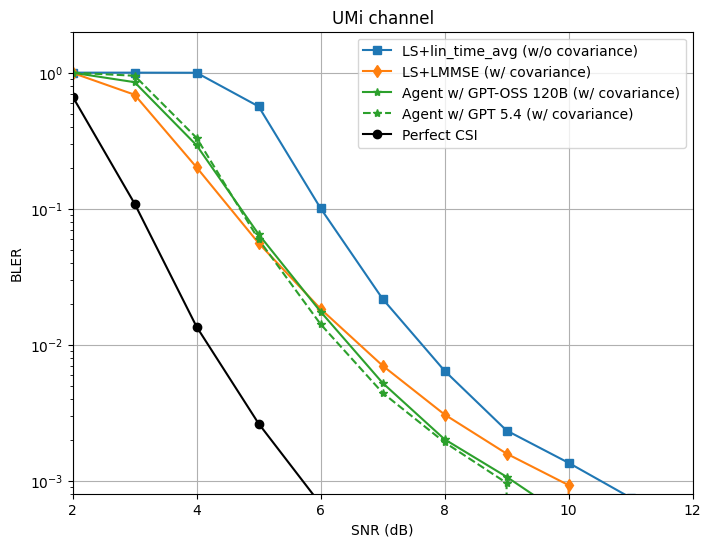

In [3]:
bler_ = BLER["umi"]

# Plot the BLER curves
plt.figure(figsize=(8, 6))
plt.semilogy(bler_["baseline"][0] + 12, bler_["baseline"][1], label='LS+lin_time_avg (w/o covariance)', marker='s', color='C0')
plt.semilogy(bler_["baseline-lmmse"][0] + 12, bler_["baseline-lmmse"][1], label='LS+LMMSE (w/ covariance)', marker='d', linestyle='-', color='C1')
plt.semilogy(bler_["agent-gpt-oss-120b"][0] + 12, bler_["agent-gpt-oss-120b"][1], label='Agent w/ GPT-OSS 120B (w/ covariance)', marker='*', linestyle='-', color='C2')
plt.semilogy(bler_["agent-gpt-5.4"][0] + 12, bler_["agent-gpt-5.4"][1], label='Agent w/ GPT 5.4 (w/ covariance)', marker='*', linestyle='--', color='C2')
plt.semilogy(bler_['perfect-csi'][0] + 12, bler_['perfect-csi'][1], label='Perfect CSI', marker='o', linestyle='-', color='k')
plt.xlabel('SNR (dB)')
plt.ylabel('BLER')
plt.ylim(8e-4, 2)
plt.xlim(2, 12)
plt.legend()
plt.grid(True)
plt.title("UMi channel")
# plt.savefig("bler_umi.png", dpi=150, bbox_inches='tight')

Text(0.5, 1.0, 'RMa channel')

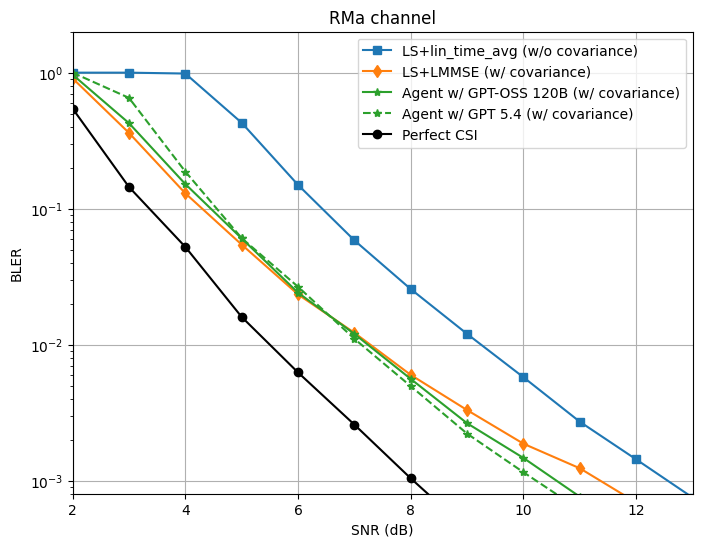

In [4]:
bler_ = BLER["rma"]

# Plot the BLER curves
plt.figure(figsize=(8, 6))
plt.semilogy(bler_["baseline"][0] + 12, bler_["baseline"][1], label='LS+lin_time_avg (w/o covariance)', marker='s', color='C0')
plt.semilogy(bler_["baseline-lmmse"][0] + 12, bler_["baseline-lmmse"][1], label='LS+LMMSE (w/ covariance)', marker='d', linestyle='-', color='C1')
plt.semilogy(bler_["agent-gpt-oss-120b"][0] + 12, bler_["agent-gpt-oss-120b"][1], label='Agent w/ GPT-OSS 120B (w/ covariance)', marker='*', linestyle='-', color='C2')
plt.semilogy(bler_["agent-gpt-5.4"][0] + 12, bler_["agent-gpt-5.4"][1], label='Agent w/ GPT 5.4 (w/ covariance)', marker='*', linestyle='--', color='C2')
plt.semilogy(bler_['perfect-csi'][0] + 12, bler_['perfect-csi'][1], label='Perfect CSI', marker='o', linestyle='-', color='k')
plt.xlabel('SNR (dB)')
plt.ylabel('BLER')
plt.ylim(8e-4, 2)
plt.xlim(2, 13)
plt.legend()
plt.grid(True)
plt.title("RMa channel")
# plt.savefig("bler_rma.png", dpi=150, bbox_inches='tight')